In [1]:
import pandas as pd
import spacy
from collections import Counter
import matplotlib.pyplot as plt

print("Imports successful")

Imports successful


In [2]:
jobs = pd.read_csv("../data/jobs_cleaned.csv")

In [3]:
jobs.shape

(123849, 15)

In [4]:
nlp = spacy.load("en_core_web_sm")

print("spaCy model loaded")

spaCy model loaded


In [5]:
skills = [
    "python",
    "sql",
    "excel",
    "power bi",
    "tableau",
    "machine learning",
    "deep learning",
    "tensorflow",
    "pytorch",
    "scikit-learn",
    "aws",
    "azure",
    "gcp",
    "docker",
    "kubernetes",
    "linux",
    "git",
    "github",
    "java",
    "javascript",
    "typescript",
    "react",
    "node.js",
    "html",
    "css",
    "c++",
    "c#",
    "mongodb",
    "mysql",
    "postgresql",
    "spark",
    "hadoop",
    "nlp",
    "data analysis",
    "data science"
]

In [6]:
def extract_skills(text):
    text = str(text).lower()

    found_skills = []

    for skill in skills:
        if skill in text:
            found_skills.append(skill)

    return found_skills

In [7]:
jobs["extracted_skills"] = jobs["clean_description"].apply(extract_skills)

In [8]:
all_skills = []

for row in jobs["extracted_skills"]:
    all_skills.extend(row)

skill_counts = Counter(all_skills)

skill_counts.most_common(10)

[('excel', 61847),
 ('aws', 22093),
 ('git', 14228),
 ('sql', 6020),
 ('python', 4898),
 ('java', 4092),
 ('data analysis', 3472),
 ('react', 3173),
 ('azure', 3025),
 ('html', 2082)]

In [9]:
skills_df = pd.DataFrame(
    skill_counts.items(),
    columns=["Skill", "Count"]
)

skills_df = skills_df.sort_values(
    by="Count",
    ascending=False
)

skills_df.head(20)

,Skill,Count
0,excel,61847
4,aws,22093
3,git,14228
5,sql,6020
13,python,4898
6,java,4092
1,data analysis,3472
2,react,3173
14,azure,3025
8,html,2082


In [10]:
total_jobs = len(jobs)

skills_df["Demand_Percentage"] = (
    skills_df["Count"] / total_jobs * 100
)

skills_df.head(20)

,Skill,Count,Demand_Percentage
0,excel,61847,49.937424
4,aws,22093,17.838658
3,git,14228,11.488183
5,sql,6020,4.860758
13,python,4898,3.954816
6,java,4092,3.304023
1,data analysis,3472,2.803414
2,react,3173,2.561991
14,azure,3025,2.442490
8,html,2082,1.681079


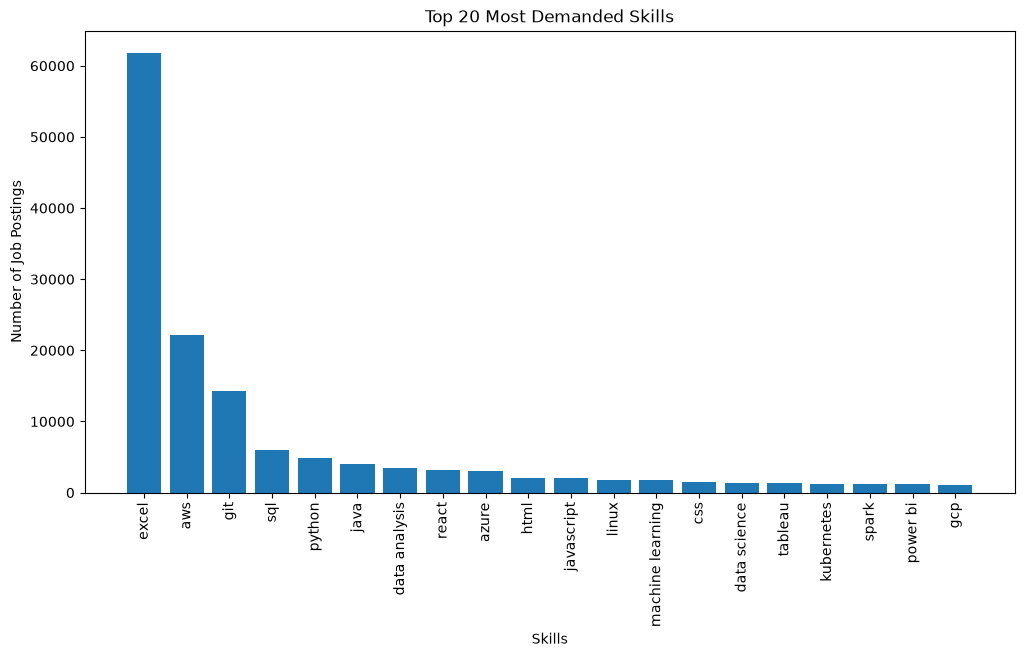

In [11]:
top20 = skills_df.head(20)

plt.figure(figsize=(12,6))

plt.bar(
    top20["Skill"],
    top20["Count"]
)

plt.xticks(rotation=90)

plt.xlabel("Skills")
plt.ylabel("Number of Job Postings")
plt.title("Top 20 Most Demanded Skills")

plt.show()

In [12]:
skills_df.to_csv(
    "../data/skills_frequency.csv",
    index=False
)

In [13]:
jobs.to_csv(
    "../data/jobs_with_skills.csv",
    index=False
)